# MulR variation with W2V 

In [2]:
from utils import * 

In [2]:
nltk_tokenizer = RegexpTokenizer("\\#+[\\w_]+[\\w\\'_\\-]*[\\w_]+|@[\\w_]+|[a-zA-Z'ÁÉÍÓÚáéíóúñÑüÜ]+-*[a-zA-Z'ÁÉÍÓÚáéíóúñÑüÜ]+|[a-zA-Z'ÁÉÍÓÚáéíóúñÑüÜ]+|[<>]?[:;=8][\\-o\\*\\']?[\\)\\]\\(\\[oOdDpP/\\:\\}\\{@\\|\\\\3\\*]|[\\)\\]\\(\\[oOdDpP/\\:\\}\\{@\\|\\\\3\\*][\\-o\\*\\']?[:;=8][<>]?|[.]+|[/,$?:;!()&%#=+{}*~.]+")

In [3]:
# Loading training data
PATH = 'Data/train.csv' 
df  = pd.read_csv(PATH,encoding='utf-8',header=None)
Xss_train = df[0]
Xss_time_train = df[1] # This value is useless in this method
Ys_train = df[2]
print("Training conversations: ",Xss_train.shape," Training labels: ",Ys_train.shape)
print()

#############################################################

# Loading training data
PATH = 'Data/test.csv'
df  = pd.read_csv(PATH,encoding='utf-8',header=None)
Xss_test = df[0]
Xss_time_test = df[1]# This value is useless in this method
Ys_test = df[2]
print("Testing conversations: ",Xss_test.shape," Testing labels: ",Ys_test.shape)
print()

Training conversations:  (66927,)  Training labels:  (66927,)

Testing conversations:  (155128,)  Testing labels:  (155128,)



# Simple preprocessing to the data

In [4]:
# Processing the 100% of the documents
clean_tr_txt = [] 
for document in Xss_train:
    new_document = [document.lower()]
    clean_tr_txt += new_document
tr_txt = clean_tr_txt
print(len(tr_txt))

66927


In [5]:
# Build Tokenizer and Vocabulary
voc_size = 7115 + 1
tokenizer = Tokenizer(num_words=voc_size)
tokenizer.fit_on_texts(tr_txt)
# Dictionary of the whole extracted vocabulary
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))
# Frequencies of words
word_counts = tokenizer.word_counts
print("Frequency of \"%s\" is %s" % ("the", word_counts["the"]))

Found 157402 unique tokens.
Frequency of "the" is 156633


In [6]:
inverted_word_index = {}
for word in word_index.keys():
    inverted_word_index[word_index[word]]=word

In [7]:
TR = tokenizer.texts_to_matrix(tr_txt, mode="count")
#TE = tokenizer.texts_to_matrix(te10_txt, mode="count")
print("TR: ", TR.shape)
print("TR[0,:10]: ", str(TR[0,:10]))
#print("TE: ", TE.shape)
#print("TE[0,:10]: ", str(TE[0,:10]))

TR:  (66927, 7116)
TR[0,:10]:  [ 0. 14.  7. 13. 10. 16. 16.  1.  2.  3.]


In [8]:
TR = tokenizer.texts_to_sequences(tr_txt)
newTR = []
for row in TR:
    nrow = " ".join(map(str, row)).split()
    newTR += [nrow]
#TR = newTR

In [9]:
s = 40
from gensim.models.word2vec import Word2Vec
w2v = Word2Vec(newTR, size=s, min_count=10, workers=10, sg=1)

In [10]:
print("len(w2v.wv.vocab): ",len(w2v.wv.vocab))

len(w2v.wv.vocab):  7115


In [11]:
DTR = np.zeros((voc_size, s), dtype=np.float)
for e in range(1,voc_size):
    DTR[int(e),:] += w2v[str(e)] 
print(DTR.shape)

(7116, 40)


In [12]:
TR = tokenizer.texts_to_matrix(tr_txt, mode="count")

In [13]:
def fit(D, DTR):
    DDR = np.zeros((len(D), DTR.shape[1]), dtype=np.float)
    d_i = 0
    for d in D:
        for term in np.nonzero(d)[0]: 
            DDR[d_i,:] += float(d[term]) * DTR[term, :]
        d_i += 1
            
    return DDR

In [14]:
start = time.time()
def BoC(TR, DTR, codebook):
    
    code, dist = vq.vq(DTR, codebook)
    new_word_metaword = {}
    for index in range(1,TR.shape[1]):
        new_word_metaword[index] = code[index] 

    TR_DDR = []
    for tr_doc in TR:
        doc = []
        for w in np.nonzero(tr_doc)[0]:
            for occurrence in range(int(tr_doc[w])):
                doc += [new_word_metaword[w]]
        histogram_of_metawords, bin_edges = histogram(doc, bins=range(len(codebook) + 1))
        TR_DDR += [histogram_of_metawords]

    TR_DDR = np.asarray(TR_DDR)
    TR_DDR=preprocessing.normalize(TR_DDR, norm='l1')
    return TR_DDR

R = [10, 50, 100, 500,1000]
codebooks = []
for r in R:
    clusterer = KMeans(n_clusters=r, n_jobs=4, random_state=1)
    clusterer.fit(DTR)
    codebook = clusterer.cluster_centers_
    codebooks += [codebook]
    
TR_DDR = BoC(TR, DTR, codebooks[0])
for i in range(1, len(codebooks)):
    TR_DDR = np.concatenate((TR_DDR, BoC(TR, DTR, codebooks[i])), axis=1)

end = time.time()
print(end - start)

107.62739038467407


In [15]:
# To the end, each document of the training set is represented with the MultR resolutions.
print(TR_DDR.shape)
print(TR_DDR[0])

(66927, 1660)
[0.03053435 0.6692112  0.03562341 ... 0.         0.         0.        ]


# Testing set preprocessing

In [16]:
# Processing the 100% of the testing documents
clean_te_txt = [] 
for document in Xss_test:
    new_document = [document.lower()]
    clean_te_txt += new_document
te_txt = clean_te_txt
print(len(te_txt)) 

155128


In [17]:
# For the testing set, the BoC function is called with the data previosly calculated in the training set
TE = tokenizer.texts_to_matrix(te_txt, mode="count")
TE_DDR = BoC(TE, DTR, codebooks[0])
for i in range(1, len(codebooks)):
    TE_DDR = np.concatenate((TE_DDR, BoC(TE, DTR, codebooks[i])), axis=1)

# To the end, each document of the testing set is represented with the MultR resolutions.
print(TE_DDR.shape)
print(TE_DDR[0]) 

(155128, 1660)
[0.08892617 0.61577181 0.15604027 ... 0.         0.         0.        ]


# Training the classifier with the resolutions

In [18]:
# Transform labels into arrays
Y_train = np.asarray(Ys_train)
Y_test = np.asarray(Ys_test)
print(Y_train.shape," ",Y_test.shape)

# Training the classfier
svr = svm.LinearSVC(class_weight='balanced')
grid=svr
grid.fit(TR_DDR, Y_train) 

# Obtaining the predictions
y_pred = grid.predict(TE_DDR)

# Performing F1 mesure of the positive (groomer) class

f1_g = np.round(metrics.f1_score(Y_test,y_pred,average='binary',pos_label=1),4)
print("F1 mesure with 100% of the information: ",f1_g)

(66927,)   (155128,)
F1 mesure with 100% of the information:  0.3887


# Online stage
## Simulating predictions with different percentage of the conversations

In [19]:
def get_percentage_document(documents,retains):
    info_documents = []
    
    # Tokenize every single document and saving them into a matrix, we save the size of the document too.
    start = time.time()
    for document in tqdm(documents):
        document_tokenize = nltk.word_tokenize(document)
        document_size = len(document_tokenize)
        info_documents.append([document_size,document_tokenize])
    end = time.time()
    print('Time: ',end-start)
    # Creating a set of documents, each of then with different percentages (%)
    final_documents = []
    for percent in retains:
        
        print("---------------------------------------- ",percent," ---------------------------------------------")
        reduce_documents = []
        if retains != 1:
            # Iteraits each doc and take only (%)
            for element in info_documents:
                document_size = element[0]
                document_tokenize = element[1]
                num_terms = round(document_size * percent)
                reduce_doc = document_tokenize[:num_terms]
                reduce_doc = ' '.join(reduce_doc)
                reduce_doc = reduce_doc.lower()
                reduce_documents.append(reduce_doc)
        else:
            print("100% of info") # In this case, we take everything
            for element in info_documents:
                document_size = element[0]
                document_tokenize = element[1]
                #num_terms = round(document_size * percent)
                reduce_doc = document_tokenize[:document_size] # In this case, we take everything
                reduce_doc = ' '.join(reduce_doc)
                reduce_doc = reduce_doc.lower()
                reduce_documents.append(reduce_doc)
        final_documents.append(reduce_documents)

    return final_documents

In [22]:
retains = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
#final_documents = get_percentage_document(Xss_test,retains)
#saving_pkl(final_documents,"Savings/finalDocuments.pkl")
final_documents = loading_pkl("Savings/finalDocuments.pkl")
print(len(final_documents[0])," ",len(final_documents[9]))

155128   155128


# Calculating partial resolutions

In [23]:
start = time.time()

TE_DDRs = []

# Iterates over each chunk (10%, 20%, 30% ... and 100%) of text avialable
for te,percent in zip(final_documents,retains):
    print("---------------------------------------- ",percent," ---------------------------------------------")
    TE = tokenizer.texts_to_matrix(te, mode="count")
    TE_DDR = BoC(TE, DTR, codebooks[0])
    for i in range(1, len(codebooks)):
        TE_DDR = np.concatenate((TE_DDR, BoC(TE, DTR, codebooks[i])), axis=1)
    print("TE_DDR: ",TE_DDR.shape)
    TE_DDRs += [TE_DDR]

end = time.time()
print(end - start)
print(len(TE_DDRs))

----------------------------------------  0.1  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.2  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.3  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.4  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.5  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.6  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.7  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.8  ---------------------------------------------
TE_DDR:  (155128, 1660)
----------------------------------------  0.9  -----------------

# Predictions with partial information

In [24]:
retains = [None,10,20,30,40,50,60,70,80,90,100]
svr = svm.LinearSVC(class_weight='balanced')
grid=svr
grid.fit(TR_DDR, Y_train) 
print("RESULTS PER CHUNK: ")
hist_f=[]

i=1
for TE_DDR in TE_DDRs:
    
    print("CLASSIFICATION FOR CHUNK:", i)
    y_pred = grid.predict(TE_DDR)

    f1_g = np.round(metrics.f1_score(Y_test,y_pred,average='binary',pos_label=1),4)
    print("F1 mesure with ",retains[i], "% of the information available: ",f1_g)
    print("="*50)

    hist_f.append(f1_g)
    i += 1

RESULTS PER CHUNK: 
CLASSIFICATION FOR CHUNK: 1
F1 mesure with  10 % of the information available:  0.084
CLASSIFICATION FOR CHUNK: 2
F1 mesure with  20 % of the information available:  0.1113
CLASSIFICATION FOR CHUNK: 3
F1 mesure with  30 % of the information available:  0.1516
CLASSIFICATION FOR CHUNK: 4
F1 mesure with  40 % of the information available:  0.193
CLASSIFICATION FOR CHUNK: 5
F1 mesure with  50 % of the information available:  0.2323
CLASSIFICATION FOR CHUNK: 6
F1 mesure with  60 % of the information available:  0.2732
CLASSIFICATION FOR CHUNK: 7
F1 mesure with  70 % of the information available:  0.3156
CLASSIFICATION FOR CHUNK: 8
F1 mesure with  80 % of the information available:  0.3382
CLASSIFICATION FOR CHUNK: 9
F1 mesure with  90 % of the information available:  0.3694
CLASSIFICATION FOR CHUNK: 10
F1 mesure with  100 % of the information available:  0.392


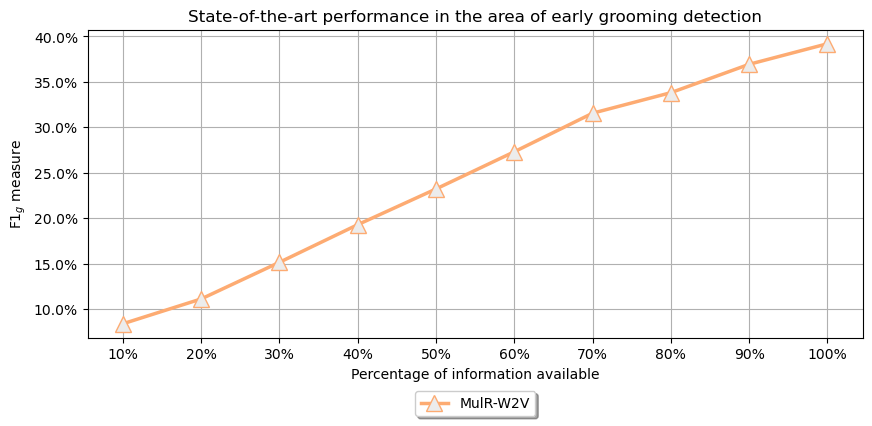

In [25]:
results = hist_f.copy()
plotting(results,"#FDAB72","^","MulR-W2V")